In [1]:
import csv
import math
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import numpy as np
import os
import pandas as pd
import sklearn
import sys
import statsmodels.api as sm
import warnings
from datetime import datetime, timedelta,date
warnings.filterwarnings('ignore')
from IPython.display import HTML
import seaborn as sns
from scipy.stats import mannwhitneyu
import statsmodels.stats.multitest
import matplotlib.pyplot as plt
from statsmodels.formula.api import mixedlm
# Deactivate Jedi so that autocomplete is faster
%config Completer.use_jedi = False
pd.options.display.max_columns = 40
pd.options.display.min_rows = 100

#pd.set_option('precision',10)

# Testing for differences in 3-month alpha diversity using Linear Mixed Effects Model
Controls for study site being a random variable

In [93]:
# Load significant asthma variables

# Definite asthma
asthma_variables = []
significant_asthma_3y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_asthma_3y.csv")
for index, row in significant_asthma_3y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in asthma_variables:
            asthma_variables.append(row['exposure variable name'])


significant_asthma_5y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_5_Years_asthma_5y.csv")
for index, row in significant_asthma_5y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in asthma_variables:
            asthma_variables.append(row['exposure variable name'])

significant_asthma_8y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_8_Years_asthma_8y.csv")
for index, row in significant_asthma_8y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in asthma_variables:
            asthma_variables.append(row['exposure variable name'])

# Definite or poassible asthma 
significant_asthma_3y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_asthma_possible_or_def_3Y.csv")
for index, row in significant_asthma_3y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in asthma_variables:
            asthma_variables.append(row['exposure variable name'])


significant_asthma_5y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_5_Years_asthma_possible_or_def_5Y.csv")
for index, row in significant_asthma_5y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in asthma_variables:
            asthma_variables.append(row['exposure variable name'])

significant_asthma_8y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_8_Years_asthma_possible_or_def_8Y.csv")
for index, row in significant_asthma_8y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in asthma_variables:
            asthma_variables.append(row['exposure variable name'])

In [94]:
vitamin_D_use_df = pd.read_csv("data/vitamin_D_use_by_infant_all_sources_3m.csv")
vitamin_D_use_df['subject_id'] = vitamin_D_use_df['subject_id'].astype("Int64")


In [96]:
wheeze_variables = []

# Recurrent wheeze
significant_wheeze_1y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_1_Year_recurrent_wheeze_binary_1y.csv")
for index, row in significant_wheeze_1y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in wheeze_variables:
            wheeze_variables.append(row['exposure variable name'])


significant_wheeze_3y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_recurrent_wheeze_binary_3y.csv")
for index, row in significant_wheeze_3y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in wheeze_variables:
            wheeze_variables.append(row['exposure variable name'])

significant_asthma_5y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_5_Years_recurrent_wheeze_binary_5y.csv")
for index, row in significant_asthma_5y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in wheeze_variables:
            wheeze_variables.append(row['exposure variable name'])

In [97]:
food_allergy_variables = []
significant_food_allergy_1y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_1_Year_food_binary_1y.csv")
for index, row in significant_food_allergy_1y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in food_allergy_variables:
            food_allergy_variables.append(row['exposure variable name'])


significant_food_allergy_3y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_food_binary_3y.csv")
for index, row in significant_food_allergy_3y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in food_allergy_variables:
            food_allergy_variables.append(row['exposure variable name'])

significant_food_allergy_5y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_5_Years_food_binary_5y.csv")
for index, row in significant_food_allergy_5y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in food_allergy_variables:
            food_allergy_variables.append(row['exposure variable name'])


In [98]:
inhalant_allergy_variables = []
significant_food_allergy_3y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_inhalant_binary_3y.csv")
for index, row in significant_food_allergy_3y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in inhalant_allergy_variables:
            inhalant_allergy_variables.append(row['exposure variable name'])

significant_food_allergy_5y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_5_Years_inhalant_binary_5y.csv")
for index, row in significant_food_allergy_5y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in inhalant_allergy_variables:
            inhalant_allergy_variables.append(row['exposure variable name'])

In [99]:
atopic_dermatitis_variables = []

significant_atopic_dermatitis_1y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_1_Year_atopic_dermatitis_status_1y.csv")
for index, row in significant_atopic_dermatitis_1y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in atopic_dermatitis_variables:
            atopic_dermatitis_variables.append(row['exposure variable name'])


significant_atopic_dermatitis_3y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_3_Years_atopic_dermatitis_status_3y.csv")
for index, row in significant_atopic_dermatitis_3y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in atopic_dermatitis_variables:
            atopic_dermatitis_variables.append(row['exposure variable name'])

significant_atopic_dermatitis_5y_exwas_variables = pd.read_csv("odds-ratios/round2_significant_exposures_5_Years_atopic_dermatitis_status_5y.csv")
for index, row in significant_atopic_dermatitis_5y_exwas_variables.iterrows():
    if row['q']<0.05:
        if row['exposure variable name'] not in atopic_dermatitis_variables:
            atopic_dermatitis_variables.append(row['exposure variable name'])

In [100]:
all_metadata_and_3m_alpha_diversity_df = pd.read_csv("data/all_metadata_and_3m_alpha_diversity.csv")

In [101]:
all_metadata_and_3m_alpha_diversity_df = pd.merge(all_metadata_and_3m_alpha_diversity_df, vitamin_D_use_df, on='subject_id', how='left')



In [102]:
covariate_columns_1y = ['EBF_6m' ,'BF_3m_status','Exact_age_months', 'vaginal_birth','older_children_in_home_3m','processing_time','num_systemic_ab_7_to_12_months','took_systemic_ab_7_to_12_months','site','BF_12m','is_caucasian']
covariate_columns_3m = ['EBF_3m','BF_3m','BF_3m_status','processing_time','Exact_age_months','vaginal_birth','older_children_in_home_3m','num_systemic_ab_0_to_3_months','took_systemic_ab_0_to_3_months','site','is_caucasian']
exposure_variables = ['vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m','vitamin_D_taken_by_infant_3m']
alpha_diversity_variables = ['inverse_simpson','shannon','Chao1']

variables_to_keep =  covariate_columns_3m + exposure_variables + alpha_diversity_variables 



In [103]:
all_metadata_and_3m_alpha_diversity_df.rename(columns={'Unnamed: 0':'sample_id'},inplace=True)
replace_names = {}
for col in all_metadata_and_3m_alpha_diversity_df.columns:
    if "." in col:
 
        col2 = col.replace(".","_")
   
        replace_names[col]=col2
all_metadata_and_3m_alpha_diversity_df.rename(columns=replace_names,inplace=True)

In [104]:
breastfeeding_status = pd.read_csv("data/breastfeeding_all_timepoints_azad.csv")
breastfeeding_status = breastfeeding_status[['SubjectNumber','BF_3m_status']]
breastfeeding_status.rename(columns={'SubjectNumber':'subject_id'},inplace=True)


In [105]:
all_metadata_and_3m_alpha_diversity_df = pd.merge(all_metadata_and_3m_alpha_diversity_df, breastfeeding_status,how="left",on="subject_id")

In [106]:
# Update to include sample processing time. Make sure to remove any samples that had a processing time > 96 hours.

sample_processing_time_3m_df = pd.read_csv("data/Child_Stool_3 months.csv")

subject_id_to_processing_period_3m = {}

for index, row in sample_processing_time_3m_df.iterrows():
    subject_id = row['SubjectNumber']
    processing_period = row['ProcessingPeriod']
    subject_id_to_processing_period_3m[subject_id]=processing_period



sample_processing_time_1y_df = pd.read_csv("data/Child_Stool_1 year.csv")

subject_id_to_processing_period_1y = {}

for index, row in sample_processing_time_1y_df.iterrows():
    subject_id = row['SubjectNumber']
    processing_period = row['ProcessingPeriod']
    subject_id_to_processing_period_1y[subject_id]=processing_period





In [107]:
for index, row in all_metadata_and_3m_alpha_diversity_df.iterrows():
    subject_id = row['subject_id']
    if subject_id in subject_id_to_processing_period_3m:
        all_metadata_and_3m_alpha_diversity_df.loc[index,"processing_time"]=subject_id_to_processing_period_3m[subject_id]


all_metadata_and_3m_alpha_diversity_df = all_metadata_and_3m_alpha_diversity_df[~all_metadata_and_3m_alpha_diversity_df['processing_time'].isna()]
print(len(all_metadata_and_3m_alpha_diversity_df))
all_metadata_and_3m_alpha_diversity_df['processing_time']=all_metadata_and_3m_alpha_diversity_df['processing_time'].astype(float)
all_metadata_and_3m_alpha_diversity_df = all_metadata_and_3m_alpha_diversity_df[all_metadata_and_3m_alpha_diversity_df['processing_time']<=96]
all_metadata_and_3m_alpha_diversity_df = all_metadata_and_3m_alpha_diversity_df[all_metadata_and_3m_alpha_diversity_df['Exact_age_months']<=4]
all_metadata_and_3m_alpha_diversity_df = all_metadata_and_3m_alpha_diversity_df[all_metadata_and_3m_alpha_diversity_df['Exact_age_months']>=2.5]


1428


In [108]:
all_metadata_and_3m_alpha_diversity_df= all_metadata_and_3m_alpha_diversity_df[variables_to_keep]

In [109]:
coef_table = pd.DataFrame(columns=['Exposure','Covariate','Index','Coef','Lower CI', 'Upper CI','P-value','significant','n','asthma associated','wheeze associated','food allergy associated','inhalant allergy associated','atopic dermatitis associated'])


# Supplementary figure 13a: Mann-Whitney U test for differences in 3-month stool alpha diversity associated with vitamin D use (exclusively breastfed)

Chao1:
  U statistic   = 45166.000
  p-value       = 0.0000013
  Cliff's delta = 0.251

Shannon:
  U statistic   = 42371.000
  p-value       = 0.0008132
  Cliff's delta = 0.173

Inverse Simpson:
  U statistic   = 41879.000
  p-value       = 0.0020344
  Cliff's delta = 0.160



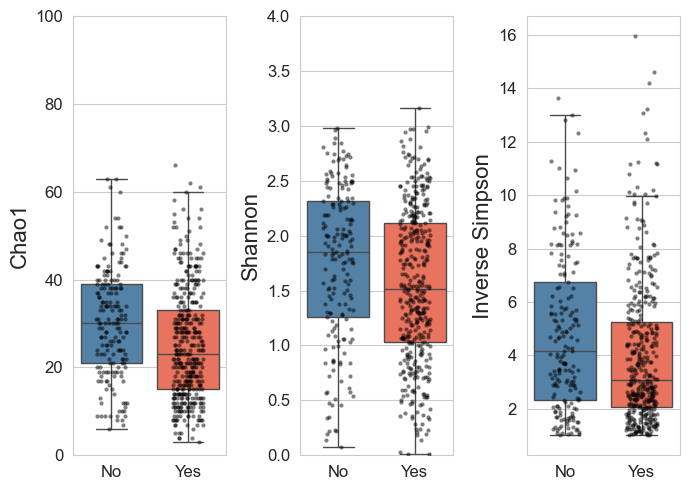

In [110]:

import pandas as pd
from scipy.stats import mannwhitneyu
import numpy as np

# Assume your DataFrame is named `df`
# Columns: 'Chao1', 'Shannon', 'Inverse_Simpson', 'vitamin_d_use_3m'


df = all_metadata_and_3m_alpha_diversity_df.copy()
df.rename(columns={'vitamin_D_taken_by_infant_3m':'vitamin_d_use_3m','shannon':'Shannon','inverse_simpson':'Inverse Simpson'},inplace=True)
df = df[df['EBF_3m'] == 1]

# Group data
group_0 = df[df['vitamin_d_use_3m'] == 0]
group_1 = df[df['vitamin_d_use_3m'] == 1]

# Define diversity metrics to test
metrics = ['Chao1', 'Shannon', 'Inverse Simpson']

titles = ['Chao1', 'Shannon', 'Inverse Simpson']

# Optional: Set custom y-axis limits
ylim_dict = {
    'Chao1': (0, 100),              # Replace with desired min/max for each
    'Shannon': (0, 4),
    'Inverse_Simpson': (0, 15)
}

# Function to calculate Cliff’s Delta
def cliffs_delta(x, y):
    n_x = len(x)
    n_y = len(y)
    more = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    delta = (more - less) / (n_x * n_y)
    return delta

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(7, 5), sharey=False)

for i, (metric, title) in enumerate(zip(metrics, titles)):
    data = df[['vitamin_d_use_3m', metric]].dropna()

    x = data[data['vitamin_d_use_3m'] == 0][metric]
    y = data[data['vitamin_d_use_3m'] == 1][metric]

    # Wilcoxon test and Cliff's delta
    stat, p_value = mannwhitneyu(x, y, alternative='two-sided')
    delta = cliffs_delta(x, y)

    print(f"{metric}:")
    print(f"  U statistic   = {stat:.3f}")
    print(f"  p-value       = {p_value:.7f}")
    print(f"  Cliff's delta = {delta:.3f}\n")

    # Plot
    sns.boxplot(data=data, x='vitamin_d_use_3m', y=metric,showfliers=False,
                palette=['steelblue', 'tomato'], ax=axes[i])
    sns.stripplot(data=data, x='vitamin_d_use_3m', y=metric,
                  color='black', size=3, jitter=0.2, alpha=0.5, ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No', 'Yes'])
    #axes[i].set_title(title, fontsize=16)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric, fontsize=16)
    axes[i].tick_params(axis='both', which='major', labelsize=12)

    # Set y-axis limits if defined
    if metric in ylim_dict:
        axes[i].set_ylim(ylim_dict[metric])

plt.tight_layout()
plt.show()

# Mann-Whitney U test for differences in 3-month stool alpha diversity associated with vitamin D use (NOT exclusively breastfed)

Chao1:
  U statistic   = 20097.000
  p-value       = 0.1593
  Cliff's delta = 0.083

Shannon:
  U statistic   = 19222.000
  p-value       = 0.5425
  Cliff's delta = 0.036

Inverse Simpson:
  U statistic   = 19317.000
  p-value       = 0.4866
  Cliff's delta = 0.041



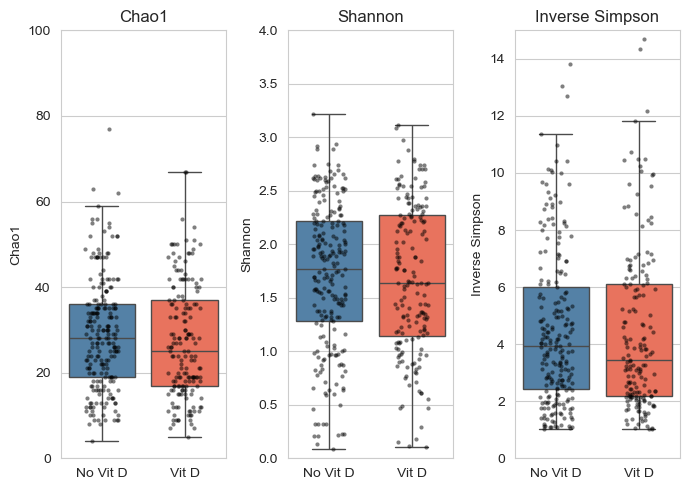

In [111]:

import pandas as pd
from scipy.stats import mannwhitneyu
import numpy as np

# Assume your DataFrame is named `df`
# Columns: 'Chao1', 'Shannon', 'Inverse_Simpson', 'vitamin_d_use_3m'


df = all_metadata_and_3m_alpha_diversity_df.copy()
df.rename(columns={'vitamin_D_taken_by_infant_3m':'vitamin_d_use_3m','shannon':'Shannon','inverse_simpson':'Inverse Simpson'},inplace=True)
df = df[df['EBF_3m'] == 0]

# Group data
group_0 = df[df['vitamin_d_use_3m'] == 0]
group_1 = df[df['vitamin_d_use_3m'] == 1]

# Define diversity metrics to test
metrics = ['Chao1', 'Shannon', 'Inverse Simpson']

titles = ['Chao1', 'Shannon', 'Inverse Simpson']

# Optional: Set custom y-axis limits
ylim_dict = {
    'Chao1': (0, 100),              # Replace with desired min/max for each
    'Shannon': (0, 4),
    'Inverse Simpson': (0, 15)
}

# Function to calculate Cliff’s Delta
def cliffs_delta(x, y):
    n_x = len(x)
    n_y = len(y)
    more = sum(i > j for i in x for j in y)
    less = sum(i < j for i in x for j in y)
    delta = (more - less) / (n_x * n_y)
    return delta

# Create subplots
fig, axes = plt.subplots(1, 3, figsize=(7, 5), sharey=False)

for i, (metric, title) in enumerate(zip(metrics, titles)):
    data = df[['vitamin_d_use_3m', metric]].dropna()

    x = data[data['vitamin_d_use_3m'] == 0][metric]
    y = data[data['vitamin_d_use_3m'] == 1][metric]

    # Wilcoxon test and Cliff's delta
    stat, p_value = mannwhitneyu(x, y, alternative='two-sided')
    delta = cliffs_delta(x, y)

    print(f"{metric}:")
    print(f"  U statistic   = {stat:.3f}")
    print(f"  p-value       = {p_value:.4f}")
    print(f"  Cliff's delta = {delta:.3f}\n")

    # Plot
    sns.boxplot(data=data, x='vitamin_d_use_3m', y=metric,showfliers=False,
                palette=['steelblue', 'tomato'], ax=axes[i])
    sns.stripplot(data=data, x='vitamin_d_use_3m', y=metric,
                  color='black', size=3, jitter=0.2, alpha=0.5, ax=axes[i])
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['No Vit D', 'Vit D'])
    axes[i].set_title(title)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(metric)

    # Set y-axis limits if defined
    if metric in ylim_dict:
        axes[i].set_ylim(ylim_dict[metric])

plt.tight_layout()
plt.show()

# Run mixed effects linear model analysis on ALL 3-months samples first

In [112]:
coef_table = pd.DataFrame(columns=['Group','Exposure','Covariate','Index','Coef','Lower CI', 'Upper CI','P-value','significant','n','n exposed','asthma associated','wheeze associated','food allergy associated','inhalant allergy associated','atopic dermatitis associated'])



for col in exposure_variables:
     

     if col not in ['subject_id','Exact_age_months','log_subject_id_x','log_subject_id_y','sample_id','num_systemic_ab_0_to_3_months','site_vancouver','site_edmonton','site_toronto','site_winnipeg','BF_3m','vaginal_birth','older_children_in_home_3m','site','family_asthma_history','inverse_simpson','shannon','Chao1']:

        if "_3m" in col or "_3M" in col or"_prenatal" in col or col.startswith("log_") or "_18WK" in col or "_birth" in col and '4m_post_birth' not in col and '5m_post_birth' not in col and '6m_post_birth' not in col and '7m_post_birth' not in col and '8m_post_birth' not in col and '9m_post_birth' not in col and '10m_post_birth' not in col and '11m_post_birth' not in col and '12m_post_birth' not in col:


            if 1: # Try:

                print("Variable="+col)

                temp_df = all_metadata_and_3m_alpha_diversity_df.copy()      
                temp_df = temp_df[~temp_df['BF_3m'].isna()]
                temp_df = temp_df[~temp_df['site'].isna()]
                temp_df = temp_df[~temp_df['vaginal_birth'].isna()]
                temp_df = temp_df[~temp_df['Exact_age_months'].isna()]
                temp_df = temp_df[~temp_df['is_caucasian'].isna()]
                temp_df = temp_df[~temp_df['older_children_in_home_3m'].isna()]
                temp_df = temp_df[~temp_df['num_systemic_ab_0_to_3_months'].isna()]
                temp_df = temp_df[~temp_df[col].isna()]


                if 1:
                    # Specify the model
                    model = mixedlm("shannon ~  BF_3m + Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])


                   


                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            
                    coefficients['Group'] = "All"
                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Shannon"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0

                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row



                    # Inverse simpson 

                    model = mixedlm("inverse_simpson ~  BF_3m + Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])

                   # model = mixedlm('inverse_simpson ~ Exact_age_months  + processing_time + '+col, 
                   #                 temp_df, 
                   #                 groups=temp_df['site'])

                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            
                    coefficients['Group'] = "All"
                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Inverse Simpson"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0
                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row


                    # Chao1 estimate 

                    model = mixedlm("Chao1 ~  BF_3m + Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])

                    

                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            
                    coefficients['Group'] = "All"   
                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Chao1"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)
                    

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0
                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row

                    

            #except:
            #    print("ERROR: "+col)

# Takes approximately 4m 25s


Variable=vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m
                            Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             shannon  
No. Observations:               811                 Method:                         REML     
No. Groups:                     4                   Scale:                          0.3693   
Min. group size:                102                 Log-Likelihood:                 -771.5339
Max. group size:                335                 Converged:                      Yes      
Mean group size:                202.8                                                        
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                   

In [113]:
all_3m_frames = [coef_table]

In [114]:
coef_frames = [coef_table]

coef_table = pd.concat(coef_frames)
coef_table[coef_table['P-value']<0.05].sort_values(by="Coef")
coef_table[coef_table['P-value']<0.05].to_csv("output/all_metadata_and_3m_alpha_diversity_df_significant_exposures.csv",index=False)

## Perform multiple testing to get q value

In [115]:
# Perform multiple testing to get q value

indices = ['Chao1','Inverse Simpson','Shannon']
frames = []
for div_index in indices:

    print(div_index)

    temp = coef_table[coef_table['Index']==div_index]
    temp = temp[temp['P-value'].notna()]
            
    if len(temp)>0:

                
        
        reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp['P-value'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
                # Adds the q-value (correct p-value) and Pass/Fail to the data frame
        temp['q']=q
        temp['reject_null']=reject

        div_index = div_index.replace(" ","_")
        
        frames.append(temp)
              
        temp.to_csv("output/Mixed-effects-model-all-metadata-and-3m-"+div_index+".csv",index=False)


Chao1
Inverse Simpson
Shannon


In [116]:
all_significant_3m_df_fdr_corrected = pd.concat(frames)

all_significant_3m_df_fdr_corrected['Exposure'] = all_significant_3m_df_fdr_corrected['Exposure'].replace('vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m','D-Vi-Sol Drops').replace('vitamin_D_taken_by_infant_3m','All Vit D Sources')


In [117]:
all_significant_3m_df_fdr_corrected

,Group,Exposure,Covariate,Index,Coef,Lower CI,Upper CI,P-value,significant,n,n exposed,asthma associated,wheeze associated,food allergy associated,inhalant allergy associated,atopic dermatitis associated,q,reject_null
2,All,D-Vi-Sol Drops,0,Chao1,-6.13,-7.96,-4.29,1.000000e-10,**,811,535,0,0,0,0,0,2.000000e-10,True
5,All,All Vit D Sources,0,Chao1,-4.06,-5.71,-2.41,1.442000e-06,**,926,546,0,0,0,0,0,1.442000e-06,True
1,All,D-Vi-Sol Drops,0,Inverse Simpson,-1.01,-1.44,-0.57,6.251300e-06,**,811,535,0,0,0,0,0,1.250260e-05,True
4,All,All Vit D Sources,0,Inverse Simpson,-0.51,-0.89,-0.14,7.610607e-03,**,926,546,0,0,0,0,0,7.610607e-03,True
0,All,D-Vi-Sol Drops,0,Shannon,-0.27,-0.37,-0.17,3.707000e-07,**,811,535,0,0,0,0,0,7.414000e-07,True
3,All,All Vit D Sources,0,Shannon,-0.14,-0.24,-0.05,1.869330e-03,**,926,546,0,0,0,0,0,1.869330e-03,True


In [118]:
# Create a function to format the tick labels with decimal notation
def log_fmt(x, pos):
    if x >= 1:
        return f"{x:.1f}"
    else:
        return f"{x:.1e}"

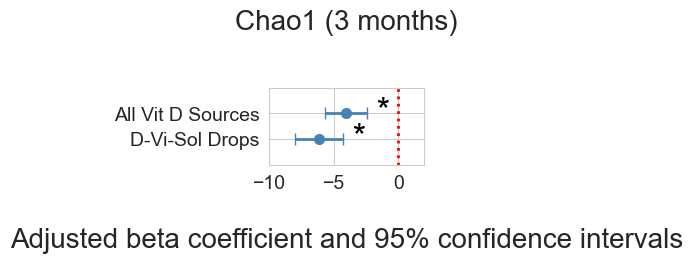

In [119]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])


import matplotlib.ticker as ticker




sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Chao1 (3 months)\n",fontsize=20, pad=20)

# Set both major and minor ticks
ax.set_xticks(range(-10, 11, 5))  # major ticks every 5

ax.tick_params(axis='x', which='minor', length=4, color='gray')

for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Chao1':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if row['q'] < 0.05 and (row['Coef']>1.1 or row['Coef']<0.9) and row['Coef']<10:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
             
            
                if row['q']<0.05:
                    label = " *"
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'], f'{label}', color='black', va='center', fontsize=25)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
ax.set_ylim(-1.0, 2)
plt.xlim(-10,2)
plt.show()


In [120]:
odds_ratio_table[odds_ratio_table['q']<0.05]

,Group,Exposure,Covariate,Index,Coef,Lower CI,Upper CI,P-value,significant,n,n exposed,asthma associated,wheeze associated,food allergy associated,inhalant allergy associated,atopic dermatitis associated,q,reject_null
5,All,All Vit D Sources,0,Chao1,-4.06,-5.71,-2.41,1.442000e-06,**,926,546,0,0,0,0,0,1.442000e-06,True
2,All,D-Vi-Sol Drops,0,Chao1,-6.13,-7.96,-4.29,1.000000e-10,**,811,535,0,0,0,0,0,2.000000e-10,True
4,All,All Vit D Sources,0,Inverse Simpson,-0.51,-0.89,-0.14,7.610607e-03,**,926,546,0,0,0,0,0,7.610607e-03,True
1,All,D-Vi-Sol Drops,0,Inverse Simpson,-1.01,-1.44,-0.57,6.251300e-06,**,811,535,0,0,0,0,0,1.250260e-05,True
3,All,All Vit D Sources,0,Shannon,-0.14,-0.24,-0.05,1.869330e-03,**,926,546,0,0,0,0,0,1.869330e-03,True
0,All,D-Vi-Sol Drops,0,Shannon,-0.27,-0.37,-0.17,3.707000e-07,**,811,535,0,0,0,0,0,7.414000e-07,True


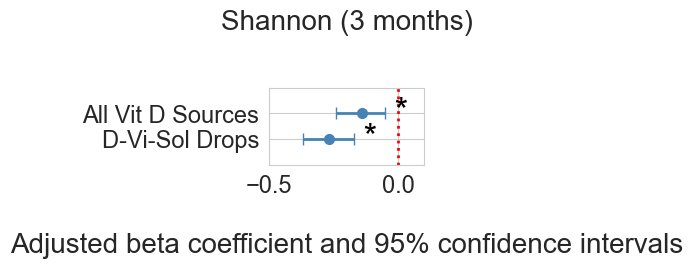

In [121]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Shannon (3 months)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Shannon':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if row['q'] < 0.05 and (row['Coef']>1.1 or row['Coef']<0.9) and row['Coef']<10:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *"
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'].replace('vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m','Infant given vitamin D (birth-3m)').replace(" (birth-3m)","").replace("Infant given ",""), f'{label}', color='black', va='center', fontsize=25)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=17)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
ax.set_ylim(-1, 2)
plt.xlim(-0.5,0.1)
plt.show()


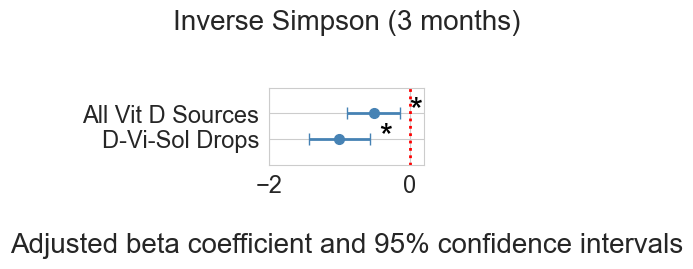

In [122]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Inverse Simpson (3 months)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Inverse Simpson':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if row['q'] < 0.05 and (row['Coef']>1.1 or row['Coef']<0.9) and row['Coef']<10:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *"
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'].replace('vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m','Infant given vitamin D (birth-3m)').replace(" (birth-3m)","").replace("Infant given ",""), f'{label}', color='black', va='center', fontsize=25)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=17)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
plt.xlim(-2,0.2)
ax.set_ylim(-1, 2)
plt.show()


In [123]:
odds_ratio_table

,Group,Exposure,Covariate,Index,Coef,Lower CI,Upper CI,P-value,significant,n,n exposed,asthma associated,wheeze associated,food allergy associated,inhalant allergy associated,atopic dermatitis associated,q,reject_null
5,All,All Vit D Sources,0,Chao1,-4.06,-5.71,-2.41,1.442000e-06,**,926,546,0,0,0,0,0,1.442000e-06,True
2,All,D-Vi-Sol Drops,0,Chao1,-6.13,-7.96,-4.29,1.000000e-10,**,811,535,0,0,0,0,0,2.000000e-10,True
4,All,All Vit D Sources,0,Inverse Simpson,-0.51,-0.89,-0.14,7.610607e-03,**,926,546,0,0,0,0,0,7.610607e-03,True
1,All,D-Vi-Sol Drops,0,Inverse Simpson,-1.01,-1.44,-0.57,6.251300e-06,**,811,535,0,0,0,0,0,1.250260e-05,True
3,All,All Vit D Sources,0,Shannon,-0.14,-0.24,-0.05,1.869330e-03,**,926,546,0,0,0,0,0,1.869330e-03,True
0,All,D-Vi-Sol Drops,0,Shannon,-0.27,-0.37,-0.17,3.707000e-07,**,811,535,0,0,0,0,0,7.414000e-07,True


# Run analysis on exclusively breastfed participant 3-month samples next

In [124]:
for col in all_metadata_and_3m_alpha_diversity_df.columns:
    print(col)

EBF_3m
BF_3m
BF_3m_status
processing_time
Exact_age_months
vaginal_birth
older_children_in_home_3m
num_systemic_ab_0_to_3_months
took_systemic_ab_0_to_3_months
site
is_caucasian
vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m
vitamin_D_taken_by_infant_3m
inverse_simpson
shannon
Chao1


In [125]:
all_metadata_and_3m_alpha_diversity_df['BF_3m_status']

1       Exclusive
2       Exclusive
3       Exclusive
4       Exclusive
5         Partial
7         Partial
9         Partial
10        Partial
11        Partial
12        Partial
13        Partial
19        Partial
22        Partial
23        Partial
24      Exclusive
25           Zero
27        Partial
28      Exclusive
29      Exclusive
30        Partial
36      Exclusive
38           Zero
39      Exclusive
40      Exclusive
41           Zero
42      Exclusive
44        Partial
45      Exclusive
46        Partial
47      Exclusive
          ...    
1403    Exclusive
1404    Exclusive
1405    Exclusive
1407    Exclusive
1408      Partial
1409      Partial
1411      Partial
1412      Partial
1413      Partial
1416    Exclusive
1419    Exclusive
1420    Exclusive
1422    Exclusive
1423      Partial
1424    Exclusive
1425    Exclusive
1427      Partial
1428      Partial
1429    Exclusive
1431      Partial
1433      Partial
1434    Exclusive
1435    Exclusive
1436      Partial
1437    Ex

In [126]:
coef_table = pd.DataFrame(columns=['Group','Exposure','Covariate','Index','Coef','Lower CI', 'Upper CI','P-value','significant','n','n exposed','asthma associated','wheeze associated','food allergy associated','inhalant allergy associated','atopic dermatitis associated'])



for col in exposure_variables:
     

     if col not in ['subject_id','Exact_age_months','log_subject_id_x','log_subject_id_y','sample_id','num_systemic_ab_0_to_3_months','site_vancouver','site_edmonton','site_toronto','site_winnipeg','BF_3m','vaginal_birth','older_children_in_home_3m','site','family_asthma_history','inverse_simpson','shannon','Chao1']:

        if "_3m" in col or "_3M" in col or"_prenatal" in col or col.startswith("log_") or "_18WK" in col or "_birth" in col and '4m_post_birth' not in col and '5m_post_birth' not in col and '6m_post_birth' not in col and '7m_post_birth' not in col and '8m_post_birth' not in col and '9m_post_birth' not in col and '10m_post_birth' not in col and '11m_post_birth' not in col and '12m_post_birth' not in col:


            if 1: # Try:

                print("Variable="+col)

                temp_df = all_metadata_and_3m_alpha_diversity_df.copy()      
                temp_df = temp_df[~temp_df['BF_3m_status'].isna()]
                temp_df = temp_df[temp_df['BF_3m_status']=='Exclusive']
                temp_df = temp_df[~temp_df['site'].isna()]
                temp_df = temp_df[~temp_df['vaginal_birth'].isna()]
                temp_df = temp_df[~temp_df['Exact_age_months'].isna()]
                temp_df = temp_df[~temp_df['is_caucasian'].isna()]
                temp_df = temp_df[~temp_df['older_children_in_home_3m'].isna()]
                temp_df = temp_df[~temp_df['num_systemic_ab_0_to_3_months'].isna()]
                temp_df = temp_df[~temp_df[col].isna()]


                if 1:
                    # Specify the model
                    model = mixedlm("shannon ~  Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])


                   


                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            

                    coefficients['Group'] = "Exclusive"

                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Shannon"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0

                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row



                    # Inverse simpson 

                    model = mixedlm("inverse_simpson ~  Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])

                   # model = mixedlm('inverse_simpson ~ Exact_age_months  + processing_time + '+col, 
                   #                 temp_df, 
                   #                 groups=temp_df['site'])

                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            
                    coefficients['Group'] = "Exclusive"
                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Inverse Simpson"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0
                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row


                    # Chao1 estimate 

                    model = mixedlm("Chao1 ~  Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])

                    

                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            
                    
                    coefficients['Group'] = "Exclusive"
                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Chao1"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)
                    

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0
                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row

                    

            #except:
            #    print("ERROR: "+col)

# Takes approximately 4m 25s


Variable=vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m
                            Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             shannon  
No. Observations:               495                 Method:                         REML     
No. Groups:                     4                   Scale:                          0.3470   
Min. group size:                48                  Log-Likelihood:                 -461.5720
Max. group size:                201                 Converged:                      Yes      
Mean group size:                123.8                                                        
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                   

In [127]:
coef_frames = [coef_table]

coef_table = pd.concat(coef_frames)
coef_table[coef_table['P-value']<0.05].sort_values(by="Coef")
coef_table[coef_table['P-value']<0.05].to_csv("output/all_metadata_and_3m_alpha_diversity_df_significant_exposures_BF3mTrue.csv",index=False)
coef_table[coef_table['P-value']<0.05].sort_values(by="Coef")

,Group,Exposure,Covariate,Index,Coef,Lower CI,Upper CI,P-value,significant,n,n exposed,asthma associated,wheeze associated,food allergy associated,inhalant allergy associated,atopic dermatitis associated
2,Exclusive,vitamins_supplements_D_Vi_Sol_D_drops_vitamin_...,0,Chao1,-8.37,-10.72,-6.02,0.000000e+00,**,495,373,0,0,0,0,0
5,Exclusive,vitamin_D_taken_by_infant_3m,0,Chao1,-6.33,-8.41,-4.25,2.400000e-09,**,555,381,0,0,0,0,0
1,Exclusive,vitamins_supplements_D_Vi_Sol_D_drops_vitamin_...,0,Inverse Simpson,-1.49,-2.04,-0.93,1.372000e-07,**,495,373,0,0,0,0,0
4,Exclusive,vitamin_D_taken_by_infant_3m,0,Inverse Simpson,-0.94,-1.42,-0.47,1.060376e-04,**,555,381,0,0,0,0,0
0,Exclusive,vitamins_supplements_D_Vi_Sol_D_drops_vitamin_...,0,Shannon,-0.41,-0.54,-0.27,2.000000e-09,**,495,373,0,0,0,0,0
3,Exclusive,vitamin_D_taken_by_infant_3m,0,Shannon,-0.26,-0.38,-0.15,1.074270e-05,**,555,381,0,0,0,0,0


## Perform multiple testing to get q value

In [128]:
# Perform multiple testing to get q value

indices = ['Chao1','Inverse Simpson','Shannon']
frames = []
stratified_3m_frames = []
for div_index in indices:

    print(div_index)

    temp = coef_table[coef_table['Index']==div_index]
    temp = temp[temp['P-value'].notna()]
            
    if len(temp)>0:

                
        
        reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp['P-value'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
                # Adds the q-value (correct p-value) and Pass/Fail to the data frame
        temp['q']=q
        temp['reject_null']=reject

        div_index = div_index.replace(" ","_")
        
        frames.append(temp)
        stratified_3m_frames.append(temp)   
              
        temp.to_csv("output/Mixed-effects-model-all-metadata-and-3m-"+div_index+".csv",index=False)


Chao1
Inverse Simpson
Shannon


In [129]:
all_significant_3m_df_fdr_corrected = pd.concat(frames)

all_significant_3m_df_fdr_corrected['Exposure'] = all_significant_3m_df_fdr_corrected['Exposure'].replace('vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m','D-Vi-Sol Drops').replace('vitamin_D_taken_by_infant_3m','All Vit D Sources')

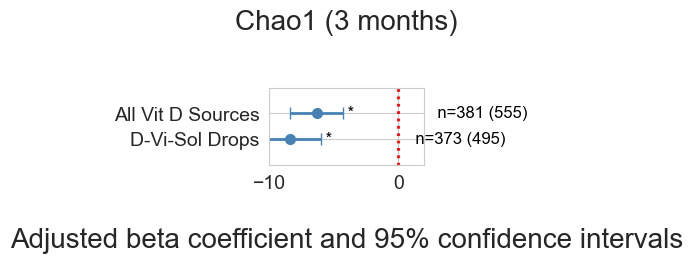

In [130]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Chao1 (3 months)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Chao1':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
ax.set_ylim(-1, 2)
plt.xlim(-10,2)
plt.show()


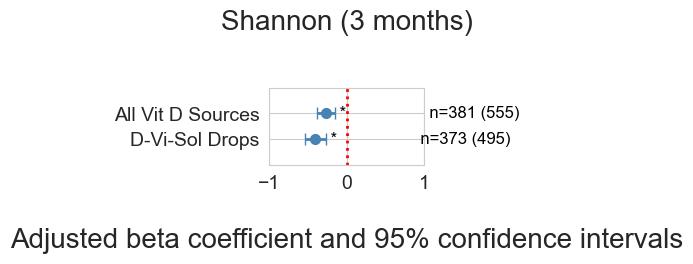

In [131]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Shannon (3 months)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Shannon':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
ax.set_ylim(-1, 2)
plt.xlim(-1,1)
plt.show()


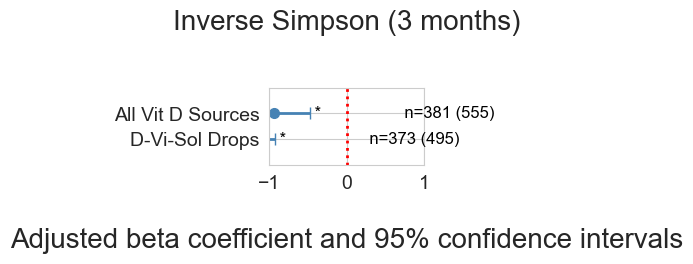

In [132]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Inverse Simpson (3 months)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Inverse Simpson':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
ax.set_ylim(-1, 2)
plt.xlim(-1,1)
plt.show()


# Run analysis on non breastfed participant 3-month samples next

In [133]:
coef_table = pd.DataFrame(columns=['Group','Exposure','Covariate','Index','Coef','Lower CI', 'Upper CI','P-value','significant','n','n exposed','asthma associated','wheeze associated','food allergy associated','inhalant allergy associated','atopic dermatitis associated'])



for col in exposure_variables:
     

     if col not in ['subject_id','Exact_age_months','log_subject_id_x','log_subject_id_y','sample_id','num_systemic_ab_0_to_3_months','site_vancouver','site_edmonton','site_toronto','site_winnipeg','BF_3m','vaginal_birth','older_children_in_home_3m','site','family_asthma_history','inverse_simpson','shannon','Chao1']:

        if "_3m" in col or "_3M" in col or"_prenatal" in col or col.startswith("log_") or "_18WK" in col or "_birth" in col and '4m_post_birth' not in col and '5m_post_birth' not in col and '6m_post_birth' not in col and '7m_post_birth' not in col and '8m_post_birth' not in col and '9m_post_birth' not in col and '10m_post_birth' not in col and '11m_post_birth' not in col and '12m_post_birth' not in col:


            if 1: # Try:

                print("Variable="+col)

                temp_df = all_metadata_and_3m_alpha_diversity_df.copy()      
                temp_df = temp_df[~temp_df['BF_3m_status'].isna()]
                temp_df = temp_df[temp_df['BF_3m_status']=='Partial']
                temp_df = temp_df[~temp_df['site'].isna()]
                temp_df = temp_df[~temp_df['vaginal_birth'].isna()]
                temp_df = temp_df[~temp_df['Exact_age_months'].isna()]
                temp_df = temp_df[~temp_df['is_caucasian'].isna()]
                temp_df = temp_df[~temp_df['older_children_in_home_3m'].isna()]
                temp_df = temp_df[~temp_df['num_systemic_ab_0_to_3_months'].isna()]
                temp_df = temp_df[~temp_df[col].isna()]


                if 1:
                    # Specify the model
                    model = mixedlm("shannon ~  Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])


                   


                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            

                    coefficients['Group'] = "Partial"

                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Shannon"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0

                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row



                    # Inverse simpson 

                    model = mixedlm("inverse_simpson ~  Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])

                   # model = mixedlm('inverse_simpson ~ Exact_age_months  + processing_time + '+col, 
                   #                 temp_df, 
                   #                 groups=temp_df['site'])

                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            
                    coefficients['Group'] = "Partial"
                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Inverse Simpson"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0
                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row


                    # Chao1 estimate 

                    model = mixedlm("Chao1 ~  Exact_age_months + processing_time + is_caucasian + num_systemic_ab_0_to_3_months + vaginal_birth +  older_children_in_home_3m + "+col ,temp_df, groups=temp_df['site'])

                    

                    # Fit the model
                    result = model.fit()

                    # Summary of the model
                    print(result.summary())

                    coefficients = pd.DataFrame(
                                    {
                                        "Coef": result.params,
                                        "Lower CI": result.conf_int()[0],
                                        "Upper CI": result.conf_int()[1]
                                    }
                                )
                            
                    
                    coefficients['Group'] = "Partial"
                    coefficients['P-value'] = round(result.pvalues,10)
                    coefficients[coefficients['P-value']<0.05]

                    coefficients['Lower CI'] = round(coefficients['Lower CI'],2)
                    coefficients['Upper CI'] = round(coefficients['Upper CI'],2)
                    coefficients['Coef'] = round(coefficients['Coef'],2)
                    coefficients['Index'] = "Chao1"
                    coefficients['Exposure'] = col
                    coefficients = coefficients.loc[col]    
                    significant_effect_row = coefficients.to_dict()
                    if significant_effect_row['P-value']<0.05 and significant_effect_row['P-value']>0.01:
                        significant_effect_row['significant']="*"
                    elif significant_effect_row['P-value']<0.01:
                        significant_effect_row['significant']="**"
                    else:
                        significant_effect_row['significant']=""

                    significant_effect_row['n']=len(temp_df)

                    exposures_df_tmp = temp_df[temp_df[col]!=0]
                    significant_effect_row['n exposed']=len(exposures_df_tmp)
                    

                    significant_effect_row['Covariate']=0

                    if col in asthma_variables:
                        significant_effect_row['asthma associated']=1
                    else:
                        significant_effect_row['asthma associated']=0

                    if col in wheeze_variables:
                        significant_effect_row['wheeze associated']=1
                    else:
                        significant_effect_row['wheeze associated']=0

                    if col in food_allergy_variables:
                        significant_effect_row['food allergy associated']=1
                    else:
                        significant_effect_row['food allergy associated']=0
                    if col in inhalant_allergy_variables:
                        significant_effect_row['inhalant allergy associated']=1
                    else:
                        significant_effect_row['inhalant allergy associated']=0

                    if col in atopic_dermatitis_variables:
                        significant_effect_row['atopic dermatitis associated']=1
                    else:
                        significant_effect_row['atopic dermatitis associated']=0



                    coef_table.loc[len(coef_table)] = significant_effect_row

                    

            #except:
            #    print("ERROR: "+col)

# Takes approximately 4m 25s


Variable=vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m
                            Mixed Linear Model Regression Results
Model:                          MixedLM             Dependent Variable:             shannon  
No. Observations:               208                 Method:                         REML     
No. Groups:                     4                   Scale:                          0.3794   
Min. group size:                35                  Log-Likelihood:                 -210.0840
Max. group size:                73                  Converged:                      Yes      
Mean group size:                52.0                                                         
---------------------------------------------------------------------------------------------
                                                   Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------------------------------------
Intercept                   

In [134]:
coef_frames = [coef_table]

coef_table = pd.concat(coef_frames)
coef_table[coef_table['P-value']<0.05].sort_values(by="Coef")
coef_table[coef_table['P-value']<0.05].to_csv("output/all_metadata_and_3m_alpha_diversity_df_significant_exposures_BF3mFalse.csv",index=False)
coef_table[coef_table['P-value']<0.05].sort_values(by="Coef")

,Group,Exposure,Covariate,Index,Coef,Lower CI,Upper CI,P-value,significant,n,n exposed,asthma associated,wheeze associated,food allergy associated,inhalant allergy associated,atopic dermatitis associated


## Perform multiple testing to get q value

In [135]:
# Perform multiple testing to get q value

indices = ['Chao1','Inverse Simpson','Shannon']
frames = []
for div_index in indices:

    print(div_index)

    temp = coef_table[coef_table['Index']==div_index]
    temp = temp[temp['P-value'].notna()]
            
    if len(temp)>0:

                
        
        reject, q, alphacSidak, alphacBonf=statsmodels.stats.multitest.multipletests(temp['P-value'], alpha=0.05, method='fdr_bh', is_sorted=False, returnsorted=False)
                # Adds the q-value (correct p-value) and Pass/Fail to the data frame
        temp['q']=q
        temp['reject_null']=reject

        div_index = div_index.replace(" ","_")
        
        frames.append(temp)
        stratified_3m_frames.append(temp)
        temp.to_csv("output/Mixed-effects-model-all-metadata-and-3m-"+div_index+".csv",index=False)


Chao1
Inverse Simpson
Shannon


In [136]:
all_significant_3m_df_fdr_corrected = pd.concat(frames)

all_significant_3m_df_fdr_corrected['Exposure'] = all_significant_3m_df_fdr_corrected['Exposure'].replace('vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m','D-Vi-Sol Drops').replace('vitamin_D_taken_by_infant_3m','All Vit D Sources')

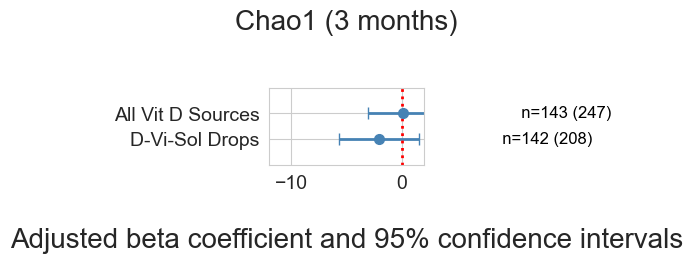

In [137]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Chao1 (3 months)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Chao1':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
ax.set_ylim(-1, 2)
plt.xlim(-12,2)
plt.show()


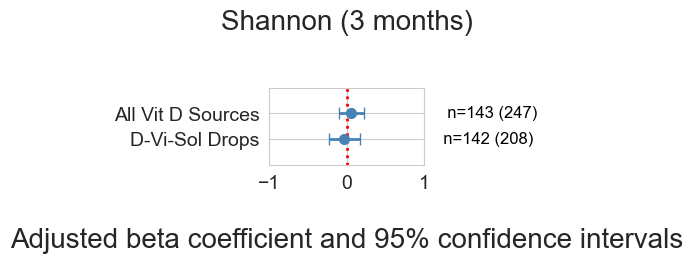

In [138]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Shannon (3 months)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Shannon':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
ax.set_ylim(-1, 2)
plt.xlim(-1,1)
plt.show()


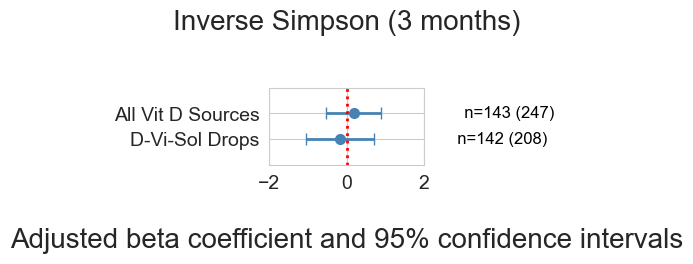

In [139]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1))
plt.title("Inverse Simpson (3 months)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Inverse Simpson':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
            
                label = "                  n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=2, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=14)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
ax.set_ylim(-1, 2)
plt.xlim(-2,2)
plt.show()


# Supplementary figure 13b: All conditions in one figure

In [140]:
all_significant_3m_df_fdr_corrected = pd.concat(stratified_3m_frames)
all_significant_3m_df_fdr_corrected['Exposure'] = all_significant_3m_df_fdr_corrected['Exposure'].replace('vitamins_supplements_D_Vi_Sol_D_drops_vitamin_D_3m','D-Vi-Sol Drops').replace('vitamin_D_taken_by_infant_3m','All Vit D Sources')

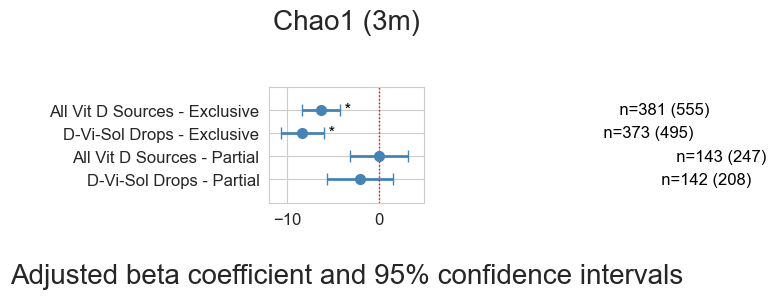

In [141]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Group","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1.5))
plt.title("Chao1 (3m)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Chao1':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']+" - "+row['Group']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
             
                label = "                                                          n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05: 
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure']+" - "+row['Group'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=1, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
plt.xlim(-12,5)
ax.set_ylim(-1, 4)
plt.show()


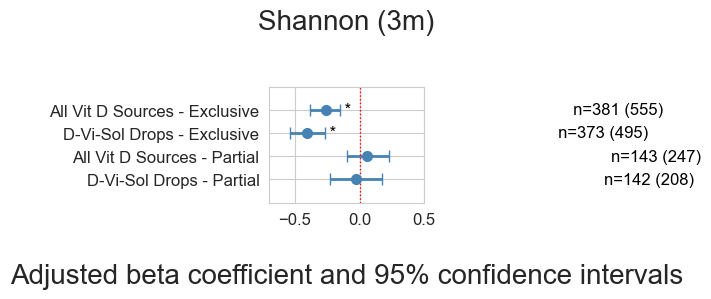

In [89]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Group","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1.5))
plt.title("Shannon (3m)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Shannon':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']+" - "+row['Group']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
             
                label = "                                                n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure']+" - "+row['Group'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=1, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
plt.xlim(-0.7,0.5)
ax.set_ylim(-1, 4)
plt.show()


In [142]:
odds_ratio_table

,Group,Exposure,Covariate,Index,Coef,Lower CI,Upper CI,P-value,significant,n,n exposed,asthma associated,wheeze associated,food allergy associated,inhalant allergy associated,atopic dermatitis associated,q,reject_null
5,Exclusive,All Vit D Sources,0,Chao1,-6.33,-8.41,-4.25,2.400000e-09,**,555,381,0,0,0,0,0,2.400000e-09,True
2,Exclusive,D-Vi-Sol Drops,0,Chao1,-8.37,-10.72,-6.02,0.000000e+00,**,495,373,0,0,0,0,0,0.000000e+00,True
5,Partial,All Vit D Sources,0,Chao1,0.08,-3.10,3.27,9.590764e-01,,247,143,0,0,0,0,0,9.590764e-01,False
2,Partial,D-Vi-Sol Drops,0,Chao1,-2.05,-5.65,1.54,2.631124e-01,,208,142,0,0,0,0,0,5.262248e-01,False
4,Exclusive,All Vit D Sources,0,Inverse Simpson,-0.94,-1.42,-0.47,1.060376e-04,**,555,381,0,0,0,0,0,1.060376e-04,True
1,Exclusive,D-Vi-Sol Drops,0,Inverse Simpson,-1.49,-2.04,-0.93,1.372000e-07,**,495,373,0,0,0,0,0,2.744000e-07,True
4,Partial,All Vit D Sources,0,Inverse Simpson,0.18,-0.53,0.89,6.195164e-01,,247,143,0,0,0,0,0,6.986689e-01,False
1,Partial,D-Vi-Sol Drops,0,Inverse Simpson,-0.17,-1.04,0.70,6.986689e-01,,208,142,0,0,0,0,0,6.986689e-01,False
3,Exclusive,All Vit D Sources,0,Shannon,-0.26,-0.38,-0.15,1.074270e-05,**,555,381,0,0,0,0,0,1.074270e-05,True
0,Exclusive,D-Vi-Sol Drops,0,Shannon,-0.41,-0.54,-0.27,2.000000e-09,**,495,373,0,0,0,0,0,4.000000e-09,True


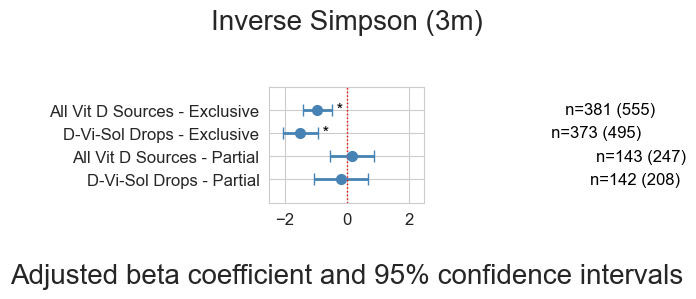

In [90]:
odds_ratio_table = all_significant_3m_df_fdr_corrected.copy()
odds_ratio_table = odds_ratio_table.sort_values(by=["Index","Group","Exposure"])

sns.set_style("whitegrid")
cfig, ax = plt.subplots(nrows=1, sharex=True, sharey=True, figsize=(2,1.5))
plt.title("Inverse Simpson (3m)\n",fontsize=20, pad=20)
for idx, row in odds_ratio_table.iloc[::-1].iterrows():

    # if "Daily" in row['exposure'] or "Weekly" in row['exposure'] or "Monthly" in row['exposure']  or "Frequency" in row['exposure']:    
        
        if row['n exposed']>=10 and row['Index']=='Inverse Simpson':
            ci = [[row['Coef'] - row['Lower CI']], [row['Upper CI'] - row['Coef']]]
            if 1:
                label = str(row['Coef'])
                
                plt.errorbar(x=[row['Coef']], y=[row['Exposure']+" - "+row['Group']], xerr=ci, ecolor='steelblue', capsize=4, linestyle='None', linewidth=2, marker="o", markersize=7, mfc="steelblue", mec="steelblue")
             
                label = "                                                n="+str(row['n exposed'])+" ("+str(row['n'])+")"
                if row['q']<0.05:
                    label = " *" + label
                # Add text to the right of the error bar
                plt.text(row['Coef'] + ci[1][0], row['Exposure']+" - "+row['Group'], f'{label}', color='black', va='center', fontsize=12)

ax.xaxis.grid(True, which='minor')

plt.axvline(x=0, linewidth=1, linestyle=':', color='red')
plt.tick_params(axis='both', which='major', labelsize=12)
plt.xlabel('\nAdjusted beta coefficient and 95% confidence intervals', fontsize=20)
plt.xlim(-2.5,2.5)
ax.set_ylim(-1, 4)
plt.show()
